In [1]:
import numpy as np
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
from scipy.signal import welch
import matplotlib as mpl
mpl.rcParams.update({'figure.figsize':[10,6],'axes.grid' : True,'font.size': 14,'savefig.facecolor':'white'})

# Parameters that define the sea surface elevation 
a = 0.5    # amplitude
wl=240     # wavelength
k = 2*np.pi/wl # wavenumber (10-unit wavelength)
h = 857000.0  # fast sampling phase altitude ... science orbit is at  891 km 

# Domain
N = 10000 # number of points
L = 40000 # length in meters
x0=10000  # beginning of domain (meters) 

print('radar incidence at x0:',x0/h,'wavee slope:', a*k)
x = x0+np.linspace(0,L, N)
dx = x[1] - x[0]
print('dx L:',dx,wl,L)

# wavenumbers definition 
delk=0.1
dk=delk*k
kp=(1+delk/2)*k
km=(1-delk/2)*k

# This is the function that gives z(x) 
def z_of_x(x, a=a, k=k,x0=x0):
    return a * (0.5*np.cos((1+delk/2)*k * (x-x0)) +0.5* np.cos((1-delk/2)*k * (x-x0)))

def zlf_of_x(x, a=a, h=h, k=k,x0=x0):
    eps=1
    xx=x-x0
    kpx=kp*xx
    kmx=km*xx
    kx=k*xx
    zp=z_of_x(x+eps)
    zm=z_of_x(x-eps)
    za=a * (0.5*np.cos(kp * (x-x0)) +0.5* np.cos(km * (x-x0))) 
    dz=-a * (kp*0.5*np.sin(kp * (x-x0)) +0.5*km* np.sin(km * (x-x0))) 
    x1=  (h/x)*za #z_of_x(xb)/(xb/h-dzdx)                       
    #term1 = z_of_x(x)+x1* dz #OK
    #term1 = za + (h/x)*za*dz  #OK
    #term1 = za -(h*a**2/(4*x))*(kp*np.cos(kpx)*np.sin(kpx)+km*np.sin(kmx)*np.cos(kpx)+  kp*np.cos(kmx)*np.sin(kpx)+km*np.sin(kmx)*np.cos(kmx))
    #term1 = za -(h*a**2/(4*x))*(kp*( np.cos(kp * (x-x0))*np.sin(kp * (x-x0)) +np.cos(km * (x-x0))*np.sin(kp * (x-x0)) )   +km*(np.sin(km * (x-x0))*np.cos(kp * (x-x0)) +np.sin(km * (x-x0))*np.cos(km * (x-x0))  ))
    #term1 = za -(h*a**2/(4*x))*(kp*( np.cos(kpx)*np.sin(kpx) +np.cos(kmx)*np.sin(kpx) )   +km*(np.sin(kmx)*np.cos(kpx ) +np.sin(kmx)*np.cos(kmx)  ))   # OK
    #term1 = za -(h*a**2/(4*x))*(k*( np.cos(kpx)*np.sin(kpx) +np.cos(kmx)*np.sin(kpx) + np.sin(kmx)*np.cos(kpx) +np.sin(kmx)*np.cos(kmx)  )+0.5*dk*( np.cos(kpx)*np.sin(kpx) +np.cos(kmx)*np.sin(kpx) - np.sin(kmx)*np.cos(kpx ) -np.sin(kmx)*np.cos(kmx)  ))
    #term1 = za -(h*a**2/(4*x))*(k*( 0.5*np.sin(2*kpx)                +np.cos(kmx)*np.sin(kpx) + np.sin(kmx)*np.cos(kpx) +0.5*np.sin(2*kmx)  )      +0.5*dk*( np.sin(2*kpx) +np.sin(dk*xx)                     -np.sin(2*kmx)  ))
    #term1 = za -(h*a**2/(4*x))*(kp*np.sin(2*kpx)                +k*np.sin(2*kx) +km*np.sin(2*kmx)  )      +0.5*dk*(+np.sin(dk*xx)                  ))

    
    #term1 = za -(h*a**2/(4*x))*(k*( np.cos(kpx)*np.sin(kpx) +np.sin(2*kx)            +np.sin(kmx)*np.cos(kmx)  )+0.5*dk*( np.cos(kpx)*np.sin(kpx) +np.sin(dk*xx) -np.sin(kmx)*np.cos(kmx)  ))
    #term1 = za -(h*a**2/(4*x))*(k*np.sin(2*kx)         +  0.5*dk*np.sin(dk*xx)  +kp*(np.cos(kpx)*np.sin(kpx)) +km*np.sin(kmx)*np.cos(kmx)  )
    term1 =    -(h*a**2/(8*x))*dk*np.sin(dk*xx)  # LF only 
    return term1
    #return a**2/(4*x/h) * delk*k*np.sin(delk*k * (x-x0)) 

def r_of_x(x,  a=a,h=h, k=k,x0=x0):
    #return x**2/(2*h)- z_of_x(x, a=a, k=k,x0=x0)
    zl=z_of_x(x, a=a, k=k,x0=x0)
    return x**2/(2*h)- zl   #+ zl**2/(2*h)+zl*x**2/(2*h**2)
    # this is an approximation for (h+r)^2=(h-z)^2+x^2 : 2hr+r2=-2hz+z2+x2    -> r=x2/2h-z




def z_of_r_first_x(r, a=a, k=k, x0=x0, h=h):
    xb = np.sqrt(2*h*r)
    x1=  (h/xb)*z_of_x(xb) #z_of_x(xb)/(xb/h-dzdx)                       
    term1 = z_of_x(xb+x1,a=a, k=k,x0=x0)    
    return term1

def z_of_r_second_order(r, a=a, k=k,x0=x0, h=h):
    #r=x**2/(2*h)  
    xb = np.sqrt(2*h*r)
    eps=1
    zc = z_of_x(xb,a=a, k=k,x0=x0)    
    zp=z_of_x(xb+eps,a=a, k=k,x0=x0)    
    zm=z_of_x(xb-eps,a=a, k=k,x0=x0)    
    dzdx=(zp-zm)/(2*eps)      #a*k*np.sin(k*xb)
    #d2z=(zp-2*zc+zm)/(eps**2)      #a*k*np.sin(k*xb)
    x1=  (h/xb)*z_of_x(xb) #z_of_x(xb)/(xb/h-dzdx)                       
    term1 = z_of_x(xb) +x1* dzdx # +0.5*x1**2* d2z    
    return term1 

def find_all_solutions(r_target,x_min=x0, x_max=x0+L,n_samples=2000,a=a, h=h, k=k,x0=x0):
# function to invert x knowing r and z of x.     
    def f(x):
        return r_of_x(x,a=a, h=h, k=k,x0=x0) - r_target
    # Sample domain
    x_grid = np.linspace(x_min, x_max, n_samples)
    f_vals = f(x_grid)

    roots = []
    eps=0.1 
    # Detect sign changes
    for i in range(len(x_grid) - 1):
        if f_vals[i] == 0:
            roots.append(x_grid[i])
        elif f_vals[i] * f_vals[i+1] < 0:
            sol = root_scalar(f, bracket=[x_grid[i], x_grid[i+1]], method='brentq')
            if sol.converged:
                roots.append(sol.root)

    # Remove duplicates (important for numerical safety)
    roots = np.array(roots)
    roots = np.unique(np.round(roots, decimals=10))

    # Compute corresponding z values
    z_vals = z_of_x(roots, a=a,k=k,x0=x0)
    slopes = (z_of_x(roots+eps*h/x[ind], a=a, k=k,x0=x0)-z_of_x(roots-eps*h/x[ind],a=a, k=k,x0=x0))/(2*eps)
    
    return roots, z_vals,slopes
    
  
r=x**2/(2*h)   # flat ocean approximation.    

# r -> (x1,x2 ...)  

#(h+r)^2=h2+2hr+r2=h^2+x^2 : 
#r=np.sqrt(h**2+x**2)-h   # flat ocean approximation.    

z2 = z_of_r_second_order(r,a=a,k=k,x0=x0,h=h ) #  -x**2/(2*h) + z
z1 = z_of_r_first_x(r,a=a,k=k,x0=x0,h=h )
z0=  z_of_x(np.sqrt(2*h*r),a=a,  k=k,x0=x0)

z  = z_of_x(x,a=a, k=k,x0=x0)


rz=np.zeros(N)
sr=np.zeros(N)
rs=np.zeros(N)
zs=np.zeros(N)
dxs=np.zeros(N)
#  quick try with sigma0 modulation ... 
#si=np.zeros(N)
#MTF=20
xsearch=4000 # search radius ... should be a function of wave amplitude
for ind in range(N): 
    fac1=0.01
    roots,vals,slopes = find_all_solutions(r[ind],x_min=x[ind]-xsearch,x_max=x[ind]+xsearch) #  -x**2/(2*h) + z
    rm=(x[ind]-0.5*dx*fac1)**2/(2*h)
    rp=(x[ind]+0.5*dx*fac1)**2/(2*h)
    dxdr0=dx*fac1/((rp-rm))
    rootm,valm,slopem =  find_all_solutions(rm   ,x_min=x[ind]-xsearch,x_max=x[ind]+xsearch) # 
    rootp,valp,slopep =  find_all_solutions(rp   ,x_min=x[ind]-xsearch,x_max=x[ind]+xsearch) # 
    rz[ind]=np.mean(vals)
    if ((len(rootm)==len(roots)) & (len(rootp)==len(roots))  ):
        dxs[ind]=np.sum(rootp-rootm)/(dx*fac1) #((rp-rm)*dxdr0)
        zs[ind]=np.sum(vals*(rootp-rootm)/(dx*fac1))
    else:
        dxs[ind]=dx #/(rp-rm)
        zs[ind]=np.sum(vals)*dx

    zs[ind]=np.sum(vals/(1-slopes))/np.sum(1/(1-slopes))
    rs[ind]=dxs[ind] # np.sum(1/(1-slopes))

wf = int(wl/dx*3)  # filter width (must be odd)
print('filter width:',wf)
# Hamming window
n = np.arange(wf)
w = 0.54 - 0.46*np.cos(2*np.pi*n/(wf-1))
w = w / np.sum(w)  # normalize

# Lanczos
#n = np.arange(wf) - (wf - 1) / 2  # Center the window
#w = np.sinc(2 * n / (wf - 1)) * np.sinc(2 * n / (wf - 1) / 2)  # Lanczos window
#w = w / np.sum(w)  # normalize


# Apply low-pass filter
rz_lp = np.convolve(np.convolve(rz, w, mode='same'), w, mode='same')
# These are for the "standard weights"
zs_lp = np.convolve(np.convolve(zs*dxs, w, mode='same'), w, mode='same')
rs_lp = np.convolve(np.convolve(dxs, w, mode='same'), w, mode='same')
# These are for alternative weights
zs_lpa = np.convolve(np.convolve(zs/dxs, w, mode='same'), w, mode='same')
rs_lpa = np.convolve(np.convolve(1/dxs, w, mode='same'), w, mode='same')
z2lf= zlf_of_x(x, a=a, k=k,x0=x0)
z2_lp = np.convolve(np.convolve(z2lf, w, mode='same'), w, mode='same')



radar incidence at x0: 0.011668611435239206 wavee slope: 0.01308996938995747
dx L: 4.000400040004024 240 40000
filter width: 179


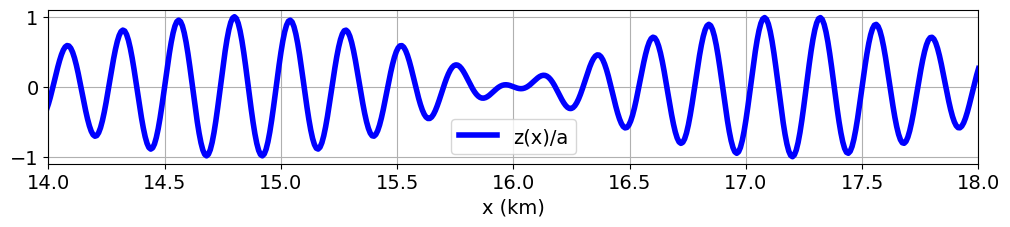

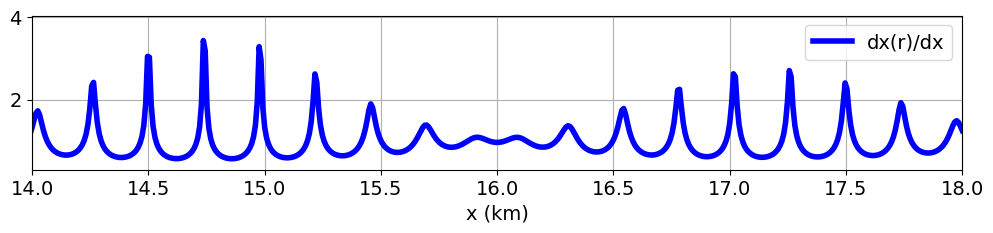

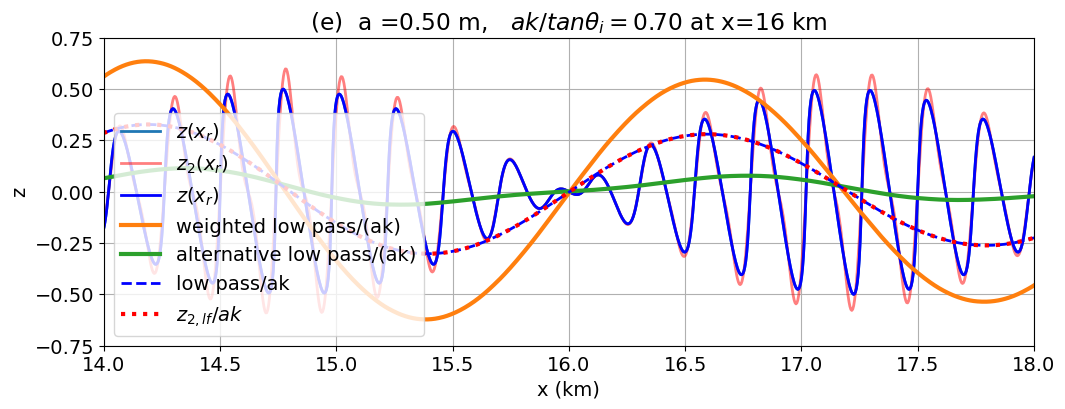

In [2]:
rangex=[14,18]

plt.figure(figsize=(12,2))
plt.plot(0.001*x[0::2],z[0::2]/a,lw=4,c='b', label='z(x)/a')
plt.xlabel('x (km)')
plt.legend()
plt.xlim(rangex)
plt.savefig("Figure_A1a.pdf")

plt.figure(figsize=(12,2))
plt.plot(0.001*x[0::2],dxs[0::2],lw=4,c='b', label='dx(r)/dx')
plt.xlabel('x (km)')
plt.legend()
plt.xlim(rangex)
plt.savefig("Figure_A1b_05m.pdf")

#plt.savefig("Figure_A1a.pdf")
#plt.plot(x,rs, label='ful2')

plt.figure(figsize=(12,4))
plt.plot(0.001*x,rz,lw=2, label=r'$z(x_r)$')
plt.plot(0.001*x,z2,lw=2,c='r',linestyle='-', alpha=0.5,label=r'$z_{2}(x_r)$')
plt.plot(0.001*x,rz,lw=2, c='b',label=r'$z(x_r)$')

######### WITH FILTER CORR ... 
#plt.plot(0.001*x,1.15*rz_lp/(a*k),lw=2 ,label='low pass/ak')
#plt.plot(0.001*x,z2lf/(a*k),lw=2,linestyle='dashed' ,label=r'$z_{2,lf}/ak$')
######### NO filter corr: we also filter the theoretical result
plt.plot(0.001*x,zs_lp/(a*k*rs_lp),lw=3 ,label='weighted low pass/(ak)')
plt.plot(0.001*x,zs_lpa/(a*k*rs_lpa),lw=3 ,label='alternative low pass/(ak)')
plt.plot(0.001*x,rz_lp/(a*k),c='b', lw=2,linestyle='dashed',label='low pass/ak')
plt.plot(0.001*x,z2_lp/(a*k),c='r',lw=3,linestyle='dotted' ,label=r'$z_{2,lf}/ak$')

plt.xlabel('x (km)')
plt.xlim(rangex)
inds=np.where(x>=16000)[0]
akn=a*k/(x[inds[0]]/h)
plt.title('(e)  a ='+f'{a:02.2f}'+r' m,   $ak / tan \theta_i=$'+f'{akn:02.2f}'+' at x=16 km')
plt.ylim([-a*1.5,a*1.5])
plt.ylabel('z')
plt.legend()
plt.savefig("Figure_A1c.pdf")
# Detrend r (very important)


inds: 50 0.06245910329848333 0.5 0.0625
dominant waves: 0.9993456527757333 0.9823837818057402 0.999345652696727
0.06245987542009441 0.06245987542009441 0.06245999156427215


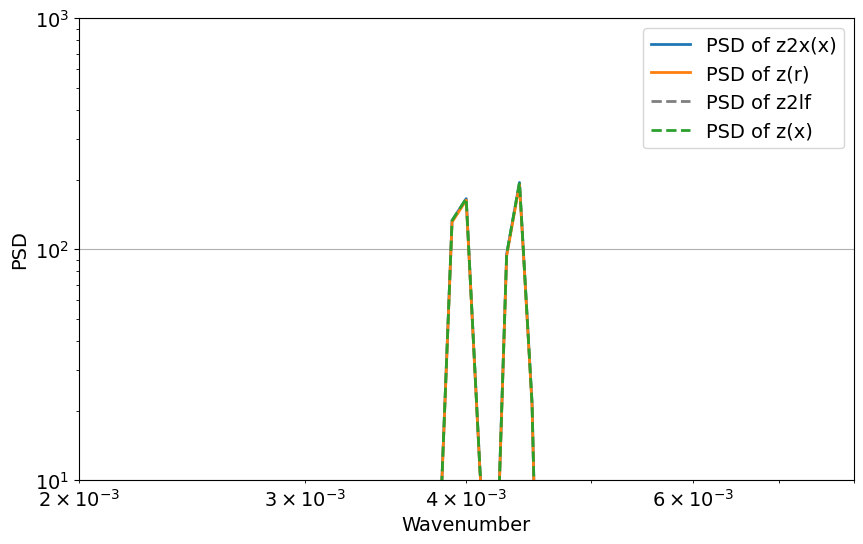

In [3]:
#plt.figure(figsize=(8,4))
#plt.plot(x, z, label='z1')
#plt.plot(x, rz, label='zr')
#plt.xlabel('x')
#plt.ylabel('elevation')

# Compute PSD
fs = 1/dx   # spatial sampling frequency
margin1=5000
margin2=1250
nfft=5000//2


k_w, PSD_z2 = welch(z2[margin1:N-margin2], fs=fs,detrend='linear',window='hann', nperseg=nfft)
k_w, PSD_r = welch(rz[margin1:N-margin2], fs=fs,detrend='linear',window='hann', nperseg=nfft)
k_w, PSD_z = welch(z[margin1:N-margin2], fs=fs,detrend='linear',window='hann', nperseg=nfft)
k_w, PSD_z2lf = welch(z2lf[margin1:N-margin2], fs=fs,detrend='linear',window='hann', nperseg=nfft)

inds=np.where((k_w > 0.001) & (k_w < 0.006))[0]
dk=k_w[1]-k_w[0]
vara=a**2/4
print('inds:',len(inds),np.sum(PSD_z[inds])*dk,a,vara)

print('dominant waves:',np.sum(PSD_z[inds])*dk/vara,np.sum(PSD_r[inds])*dk/vara,np.sum(PSD_z2[inds])*dk/vara)

print(np.sum(PSD_r)*dk,np.sum(PSD_r)*dk,np.sum(PSD_z)*dk)

plt.loglog(k_w, PSD_z2,  lw=2, label='PSD of z2x(x)')
plt.loglog(k_w, PSD_r,   lw=2, label='PSD of z(r)')
plt.loglog(k_w, PSD_z2lf,c='k',alpha=0.5,lw=2, label='PSD of z2lf',ls='dashed')
plt.loglog(k_w, PSD_z   ,lw=2, label='PSD of z(x)',ls='dashed')
plt.xlabel('Wavenumber')
plt.ylabel('PSD')
plt.ylim([10,1000])
plt.xlim([0.002,0.008])
plt.legend()
plt.show()

In [4]:
h=857E3
RE=20000E3/np.pi
fac=1/np.sqrt(1+h/RE)
print(fac,h/RE,h,RE)

0.9388048183304807 0.13461724520632265 857000.0 6366197.7236758135


In [5]:
k0=2*np.pi/0.008;B=10
xm=35000
r=np.sqrt(h**2+xm**2)
ti=xm/h
kz=k0*B/(r*np.sin(ti))
print(k0,r,np.exp(-(kz*1.5/4)**2),np.exp(-(kz*13/4)**2),np.log(10))

785.3981633974482 857714.4046825843 0.9929516272062463 0.587848704725099 2.302585092994046
